# Random Forest Hyperparameter Tuning

**Objective**: Systematic hyperparameter tuning for Random Forest classifier across multiple tasks.

## Hyperparameter Grid:
1. **n_estimators**: Number of trees `[50, 100, 200, 300]`
2. **max_depth**: Maximum tree depth `[10, 20, 30, None]`
3. **min_samples_split**: Minimum samples to split `[2, 5, 10, 15]`
4. **min_samples_leaf**: Minimum samples in leaf `[1, 2, 4, 8]`

## Tasks:
- Country Classification (16 classes)
- Time of Day Classification (4 classes)
- Activity Classification (4 classes)

## Output:
Results saved to `results/hyperparameter_tuning/random_forest/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Setup paths
START_DIR = Path.cwd()
PROJECT_ROOT = START_DIR.parent
DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_DIR = DATA_DIR / 'features'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'hyperparameter_tuning' / 'random_forest'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Setup complete.")
print(f"Results will be saved to: {RESULTS_DIR}")

Setup complete.
Results will be saved to: c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\random_forest


## 1. Load Cleaned Data & Prepare Labels

In [2]:
# 1. Load Metadata
cleaned_df = pd.read_csv(DATA_DIR / 'processed' / 'cleaned_dataset.csv')

# 2. Derive Activity
def derive_activity(text):
    text = str(text).lower()
    keywords = {
        'Nature': ['park', 'garden', 'mountain', 'lake', 'river', 'nature', 'hike', 'hiking', 'forest', 'valley', 'waterfall', 'beach', 'sea', 'ocean', 'island', 'sand', 'cave', 'rock', 'hill', 'view', 'landscape', 'sunrise', 'sunset'],
        'History': ['museum', 'castle', 'palace', 'temple', 'church', 'cathedral', 'history', 'ancient', 'monument', 'ruins', 'art', 'statue', 'shrine', 'mosque', 'tomb', 'archaeology', 'historic'],
        'Urban': ['city', 'street', 'building', 'bridge', 'tower', 'square', 'market', 'shop', 'downtown', 'urban', 'skyline', 'hotel', 'mall', 'road', 'town', 'architecture', 'skyscraper'],
    }
    for cat in ['History', 'Urban', 'Nature']:
        if any(w in text for w in keywords[cat]):
            return cat
    return 'Leisure/Other'

cleaned_df['Activity'] = cleaned_df['Description'].apply(derive_activity)

# 3. Filter Valid Data
CONFIG = {
    'top_n_countries': 15,
    'valid_times': ['Morning', 'Afternoon', 'Evening', 'Night'],
    'test_size': 0.20,
    'random_state': 42
}

valid_mask = cleaned_df['Time_of_Day_Standardized'].isin(CONFIG['valid_times'])
df = cleaned_df[valid_mask].copy().reset_index(drop=True)
valid_indices = np.where(valid_mask)[0]

print(f"Valid samples: {len(df)}")

# 4. Encoders
country_counts_all = df['Country_Standardized'].value_counts()
top_countries = set(country_counts_all.head(CONFIG['top_n_countries']).index)
df['Country_Grouped'] = df['Country_Standardized'].apply(lambda x: x if x in top_countries else 'Other')

country_encoder = LabelEncoder()
country_encoder.fit(sorted(list(top_countries) + ['Other']))
time_encoder = LabelEncoder()
time_encoder.fit(CONFIG['valid_times'])
activity_encoder = LabelEncoder()
activity_encoder.fit(sorted(df['Activity'].unique()))

y_country = country_encoder.transform(df['Country_Grouped'].values)
y_time = time_encoder.transform(df['Time_of_Day_Standardized'].values)
y_activity = activity_encoder.transform(df['Activity'].values)

# 5. Stratified Split
strat_key = (df['Country_Grouped'] + '_' + df['Time_of_Day_Standardized'] + '_' + df['Activity'])
strat_counts = strat_key.value_counts()
strat_key_safe = strat_key.apply(lambda x: 'OTHER' if strat_counts[x] < 2 else x)

train_idx_global, test_idx_global = train_test_split(
    list(range(len(df))), 
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=strat_key_safe.values
)

print(f"Split prepared: {len(train_idx_global)} Train, {len(test_idx_global)} Test")

Valid samples: 945
Split prepared: 756 Train, 189 Test


## 2. Load Features & Evaluation Function

In [3]:
def evaluate_model(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

# Load normalized features
features_all = np.load(FEATURES_DIR / 'places_features_pretrained_normalized.npy')

# Filter valid indices
X_valid = features_all[valid_indices]

# Split
X_train = X_valid[train_idx_global]
X_test = X_valid[test_idx_global]

# Get targets
y_train_c, y_test_c = y_country[train_idx_global], y_country[test_idx_global]
y_train_t, y_test_t = y_time[train_idx_global], y_time[test_idx_global]
y_train_a, y_test_a = y_activity[train_idx_global], y_activity[test_idx_global]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (756, 2432)
X_test shape: (189, 2432)


## 3. Random Forest Hyperparameter Tuning

In [4]:
# Hyperparameter grid
n_estimators_list = [50, 100, 200, 300]
max_depth_list = [10, 20, 30, None]
min_samples_split_list = [2, 5, 10, 15]
min_samples_leaf_list = [1, 2, 4, 8]

results_list = []
total_configs = len(n_estimators_list) * len(max_depth_list)

print(f"Starting hyperparameter tuning ({total_configs} configurations)...")
print("Testing n_estimators and max_depth as primary parameters")
print("Using fixed min_samples_split=2, min_samples_leaf=1 for this sweep")
print("="*80)

config_num = 0
for n_est in n_estimators_list:
    for max_d in max_depth_list:
        config_num += 1
        
        # Train models for each task
        rf_c = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=2,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )
        rf_t = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=2,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )
        rf_a = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=2,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=42
        )
        
        # Fit models
        rf_c.fit(X_train_scaled, y_train_c)
        rf_t.fit(X_train_scaled, y_train_t)
        rf_a.fit(X_train_scaled, y_train_a)
        
        # Predictions
        pred_c = rf_c.predict(X_test_scaled)
        pred_t = rf_t.predict(X_test_scaled)
        pred_a = rf_a.predict(X_test_scaled)
        
        # Evaluate
        res_c = evaluate_model(y_test_c, pred_c)
        res_t = evaluate_model(y_test_t, pred_t)
        res_a = evaluate_model(y_test_a, pred_a)
        
        # Store results
        result = {
            'n_estimators': n_est,
            'max_depth': max_d if max_d is not None else 'None',
            'min_samples_split': 2,
            'min_samples_leaf': 1,
            'country_accuracy': res_c['accuracy'],
            'country_f1_macro': res_c['f1_macro'],
            'country_f1_weighted': res_c['f1_weighted'],
            'time_accuracy': res_t['accuracy'],
            'time_f1_macro': res_t['f1_macro'],
            'time_f1_weighted': res_t['f1_weighted'],
            'activity_accuracy': res_a['accuracy'],
            'activity_f1_macro': res_a['f1_macro'],
            'activity_f1_weighted': res_a['f1_weighted'],
            'avg_accuracy': (res_c['accuracy'] + res_t['accuracy'] + res_a['accuracy']) / 3
        }
        results_list.append(result)
        
        print(f"[{config_num}/{total_configs}] n_estimators={n_est}, max_depth={max_d} -> "
              f"Country: {res_c['accuracy']:.4f}, Time: {res_t['accuracy']:.4f}, "
              f"Activity: {res_a['accuracy']:.4f}, Avg: {result['avg_accuracy']:.4f}")

print("\n" + "="*80)
print("Testing min_samples_split and min_samples_leaf as primary parameters")
print("Using best n_estimators and max_depth from previous sweep")
print("="*80)

# Find best n_estimators and max_depth from previous sweep
temp_df = pd.DataFrame(results_list)
best_config = temp_df.loc[temp_df['avg_accuracy'].idxmax()]
best_n_est = int(best_config['n_estimators'])
best_max_d = best_config['max_depth']
if best_max_d == 'None':
    best_max_d = None
else:
    best_max_d = int(best_max_d)

print(f"Best from first sweep: n_estimators={best_n_est}, max_depth={best_max_d}")

total_configs2 = len(min_samples_split_list) * len(min_samples_leaf_list)
config_num = 0

for min_split in min_samples_split_list:
    for min_leaf in min_samples_leaf_list:
        # Skip default combination (already tested)
        if min_split == 2 and min_leaf == 1:
            continue
            
        config_num += 1
        
        # Train models for each task
        rf_c = RandomForestClassifier(
            n_estimators=best_n_est,
            max_depth=best_max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            n_jobs=-1,
            random_state=42
        )
        rf_t = RandomForestClassifier(
            n_estimators=best_n_est,
            max_depth=best_max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            n_jobs=-1,
            random_state=42
        )
        rf_a = RandomForestClassifier(
            n_estimators=best_n_est,
            max_depth=best_max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            n_jobs=-1,
            random_state=42
        )
        
        # Fit models
        rf_c.fit(X_train_scaled, y_train_c)
        rf_t.fit(X_train_scaled, y_train_t)
        rf_a.fit(X_train_scaled, y_train_a)
        
        # Predictions
        pred_c = rf_c.predict(X_test_scaled)
        pred_t = rf_t.predict(X_test_scaled)
        pred_a = rf_a.predict(X_test_scaled)
        
        # Evaluate
        res_c = evaluate_model(y_test_c, pred_c)
        res_t = evaluate_model(y_test_t, pred_t)
        res_a = evaluate_model(y_test_a, pred_a)
        
        # Store results
        result = {
            'n_estimators': best_n_est,
            'max_depth': best_max_d if best_max_d is not None else 'None',
            'min_samples_split': min_split,
            'min_samples_leaf': min_leaf,
            'country_accuracy': res_c['accuracy'],
            'country_f1_macro': res_c['f1_macro'],
            'country_f1_weighted': res_c['f1_weighted'],
            'time_accuracy': res_t['accuracy'],
            'time_f1_macro': res_t['f1_macro'],
            'time_f1_weighted': res_t['f1_weighted'],
            'activity_accuracy': res_a['accuracy'],
            'activity_f1_macro': res_a['f1_macro'],
            'activity_f1_weighted': res_a['f1_weighted'],
            'avg_accuracy': (res_c['accuracy'] + res_t['accuracy'] + res_a['accuracy']) / 3
        }
        results_list.append(result)
        
        print(f"[{config_num}/{total_configs2-1}] min_samples_split={min_split}, min_samples_leaf={min_leaf} -> "
              f"Country: {res_c['accuracy']:.4f}, Time: {res_t['accuracy']:.4f}, "
              f"Activity: {res_a['accuracy']:.4f}, Avg: {result['avg_accuracy']:.4f}")

results_df = pd.DataFrame(results_list)
print("\n" + "="*80)
print("Hyperparameter tuning complete!")
print("="*80)

Starting hyperparameter tuning (16 configurations)...
Testing n_estimators and max_depth as primary parameters
Using fixed min_samples_split=2, min_samples_leaf=1 for this sweep
[1/16] n_estimators=50, max_depth=10 -> Country: 0.5291, Time: 0.5873, Activity: 0.6614, Avg: 0.5926
[2/16] n_estimators=50, max_depth=20 -> Country: 0.5767, Time: 0.5979, Activity: 0.6825, Avg: 0.6190
[3/16] n_estimators=50, max_depth=30 -> Country: 0.6243, Time: 0.5873, Activity: 0.6772, Avg: 0.6296
[4/16] n_estimators=50, max_depth=None -> Country: 0.6243, Time: 0.5926, Activity: 0.6772, Avg: 0.6314
[5/16] n_estimators=100, max_depth=10 -> Country: 0.5450, Time: 0.6085, Activity: 0.6878, Avg: 0.6138
[6/16] n_estimators=100, max_depth=20 -> Country: 0.5926, Time: 0.6085, Activity: 0.6667, Avg: 0.6226
[7/16] n_estimators=100, max_depth=30 -> Country: 0.5926, Time: 0.5979, Activity: 0.6561, Avg: 0.6155
[8/16] n_estimators=100, max_depth=None -> Country: 0.5979, Time: 0.6032, Activity: 0.6561, Avg: 0.6190
[9/16]

## 4. Analyze Results

In [5]:
# Save Results CSV
csv_path = RESULTS_DIR / 'rf_hyperparameter_results.csv'
results_df.to_csv(csv_path, index=False)
print(f"✓ Saved results to {csv_path}")

# Save JSON Results
json_results = results_df.to_dict('records')
json_path = RESULTS_DIR / 'rf_hyperparameter_results.json'
with open(json_path, 'w') as f:
    json.dump(json_results, f, indent=2)
print(f"✓ Saved JSON to {json_path}")

# Find best configurations
print("\n" + "="*80)
print("BEST CONFIGURATIONS")
print("="*80)

best_country = results_df.loc[results_df['country_accuracy'].idxmax()]
print(f"\nBest for Country Classification:")
print(f"  n_estimators={best_country['n_estimators']}, max_depth={best_country['max_depth']}, "
      f"min_samples_split={best_country['min_samples_split']}, min_samples_leaf={best_country['min_samples_leaf']}")
print(f"  Accuracy: {best_country['country_accuracy']:.4f}, F1-Macro: {best_country['country_f1_macro']:.4f}")

best_time = results_df.loc[results_df['time_accuracy'].idxmax()]
print(f"\nBest for Time Classification:")
print(f"  n_estimators={best_time['n_estimators']}, max_depth={best_time['max_depth']}, "
      f"min_samples_split={best_time['min_samples_split']}, min_samples_leaf={best_time['min_samples_leaf']}")
print(f"  Accuracy: {best_time['time_accuracy']:.4f}, F1-Macro: {best_time['time_f1_macro']:.4f}")

best_activity = results_df.loc[results_df['activity_accuracy'].idxmax()]
print(f"\nBest for Activity Classification:")
print(f"  n_estimators={best_activity['n_estimators']}, max_depth={best_activity['max_depth']}, "
      f"min_samples_split={best_activity['min_samples_split']}, min_samples_leaf={best_activity['min_samples_leaf']}")
print(f"  Accuracy: {best_activity['activity_accuracy']:.4f}, F1-Macro: {best_activity['activity_f1_macro']:.4f}")

best_overall = results_df.loc[results_df['avg_accuracy'].idxmax()]
print(f"\nBest Overall (Average Accuracy):")
print(f"  n_estimators={best_overall['n_estimators']}, max_depth={best_overall['max_depth']}, "
      f"min_samples_split={best_overall['min_samples_split']}, min_samples_leaf={best_overall['min_samples_leaf']}")
print(f"  Average Accuracy: {best_overall['avg_accuracy']:.4f}")

✓ Saved results to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\random_forest\rf_hyperparameter_results.csv
✓ Saved JSON to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\random_forest\rf_hyperparameter_results.json

BEST CONFIGURATIONS

Best for Country Classification:
  n_estimators=50, max_depth=30, min_samples_split=2, min_samples_leaf=1
  Accuracy: 0.6243, F1-Macro: 0.5440

Best for Time Classification:
  n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1
  Accuracy: 0.6138, F1-Macro: 0.3920

Best for Activity Classification:
  n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1
  Accuracy: 0.6878, F1-Macro: 0.5621

Best Overall (Average Accuracy):
  n_estimators=200, max_depth=20, min_samples_split=2, min_samples_leaf=1
 

## 5. Visualizations

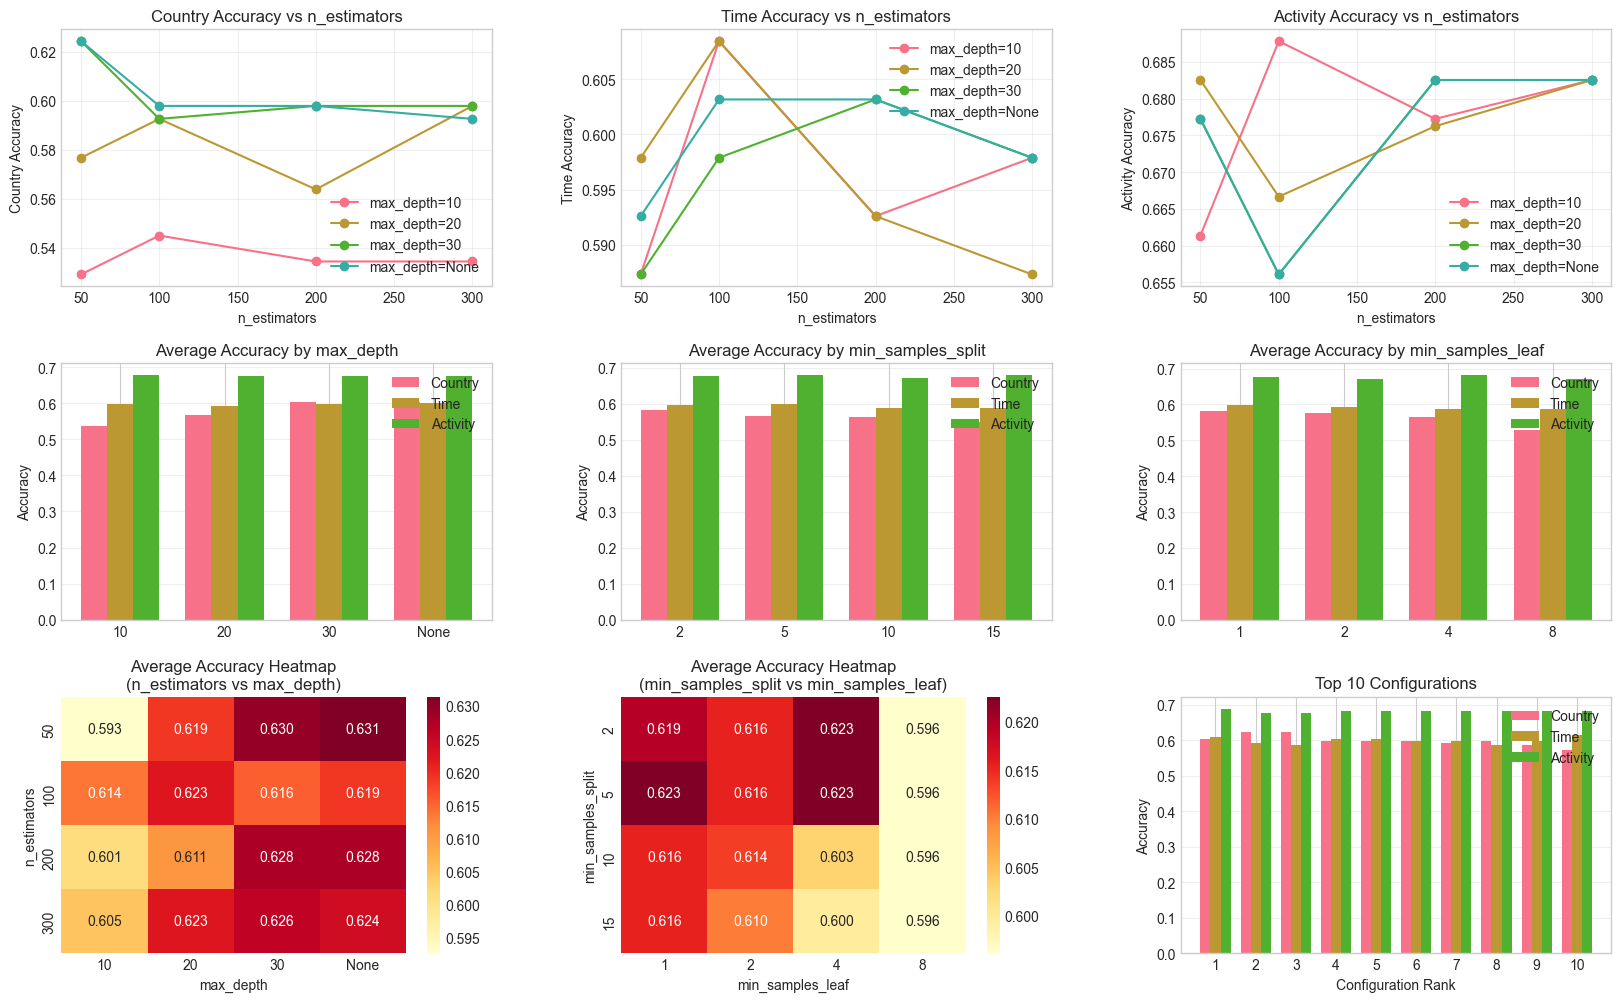

✓ Saved visualization to c:\Users\qadim\OneDrive - student.birzeit.edu\birzeit\5_year_1\machine_learning\assingment_3_project\travel-recommender-system\results\hyperparameter_tuning\random_forest\rf_hyperparameter_comparison.png


In [6]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. n_estimators vs Accuracy for different max_depth
ax1 = fig.add_subplot(gs[0, 0])
for max_d in results_df['max_depth'].unique():
    subset = results_df[results_df['max_depth'] == max_d]
    # Group by n_estimators and average over other params
    grouped = subset.groupby('n_estimators')['country_accuracy'].mean()
    ax1.plot(grouped.index, grouped.values, marker='o', label=f'max_depth={max_d}')
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Country Accuracy')
ax1.set_title('Country Accuracy vs n_estimators')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
for max_d in results_df['max_depth'].unique():
    subset = results_df[results_df['max_depth'] == max_d]
    grouped = subset.groupby('n_estimators')['time_accuracy'].mean()
    ax2.plot(grouped.index, grouped.values, marker='o', label=f'max_depth={max_d}')
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('Time Accuracy')
ax2.set_title('Time Accuracy vs n_estimators')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
for max_d in results_df['max_depth'].unique():
    subset = results_df[results_df['max_depth'] == max_d]
    grouped = subset.groupby('n_estimators')['activity_accuracy'].mean()
    ax3.plot(grouped.index, grouped.values, marker='o', label=f'max_depth={max_d}')
ax3.set_xlabel('n_estimators')
ax3.set_ylabel('Activity Accuracy')
ax3.set_title('Activity Accuracy vs n_estimators')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 2. max_depth comparison (bar chart)
ax4 = fig.add_subplot(gs[1, 0])
max_depth_avg = results_df.groupby('max_depth')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(max_depth_avg.index))
width = 0.25
ax4.bar(x_pos - width, max_depth_avg['country_accuracy'], width, label='Country')
ax4.bar(x_pos, max_depth_avg['time_accuracy'], width, label='Time')
ax4.bar(x_pos + width, max_depth_avg['activity_accuracy'], width, label='Activity')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(max_depth_avg.index)
ax4.set_ylabel('Accuracy')
ax4.set_title('Average Accuracy by max_depth')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 3. min_samples_split comparison
ax5 = fig.add_subplot(gs[1, 1])
split_avg = results_df.groupby('min_samples_split')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(split_avg.index))
ax5.bar(x_pos - width, split_avg['country_accuracy'], width, label='Country')
ax5.bar(x_pos, split_avg['time_accuracy'], width, label='Time')
ax5.bar(x_pos + width, split_avg['activity_accuracy'], width, label='Activity')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(split_avg.index)
ax5.set_ylabel('Accuracy')
ax5.set_title('Average Accuracy by min_samples_split')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 4. min_samples_leaf comparison
ax6 = fig.add_subplot(gs[1, 2])
leaf_avg = results_df.groupby('min_samples_leaf')[['country_accuracy', 'time_accuracy', 'activity_accuracy']].mean()
x_pos = np.arange(len(leaf_avg.index))
ax6.bar(x_pos - width, leaf_avg['country_accuracy'], width, label='Country')
ax6.bar(x_pos, leaf_avg['time_accuracy'], width, label='Time')
ax6.bar(x_pos + width, leaf_avg['activity_accuracy'], width, label='Activity')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(leaf_avg.index)
ax6.set_ylabel('Accuracy')
ax6.set_title('Average Accuracy by min_samples_leaf')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 5. Heatmap: n_estimators vs max_depth (avg accuracy)
ax7 = fig.add_subplot(gs[2, 0])
pivot_data = results_df.groupby(['n_estimators', 'max_depth'])['avg_accuracy'].mean().reset_index()
pivot_table = pivot_data.pivot(index='n_estimators', columns='max_depth', values='avg_accuracy')
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax7)
ax7.set_title('Average Accuracy Heatmap\n(n_estimators vs max_depth)')

# 6. Heatmap: min_samples_split vs min_samples_leaf
ax8 = fig.add_subplot(gs[2, 1])
pivot_data2 = results_df.groupby(['min_samples_split', 'min_samples_leaf'])['avg_accuracy'].mean().reset_index()
pivot_table2 = pivot_data2.pivot(index='min_samples_split', columns='min_samples_leaf', values='avg_accuracy')
sns.heatmap(pivot_table2, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax8)
ax8.set_title('Average Accuracy Heatmap\n(min_samples_split vs min_samples_leaf)')

# 7. Top 10 configurations comparison
ax9 = fig.add_subplot(gs[2, 2])
top_10 = results_df.nlargest(10, 'avg_accuracy')
config_labels = [f"{i+1}" for i in range(len(top_10))]
x_pos = np.arange(len(top_10))
ax9.bar(x_pos - width, top_10['country_accuracy'].values, width, label='Country')
ax9.bar(x_pos, top_10['time_accuracy'].values, width, label='Time')
ax9.bar(x_pos + width, top_10['activity_accuracy'].values, width, label='Activity')
ax9.set_xticks(x_pos)
ax9.set_xticklabels(config_labels)
ax9.set_ylabel('Accuracy')
ax9.set_xlabel('Configuration Rank')
ax9.set_title('Top 10 Configurations')
ax9.legend()
ax9.grid(True, alpha=0.3, axis='y')

plt.savefig(RESULTS_DIR / 'rf_hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization to {RESULTS_DIR / 'rf_hyperparameter_comparison.png'}")

## 6. Summary Statistics

In [7]:
# Display summary statistics
print("\n" + "="*80)
print("HYPERPARAMETER IMPACT SUMMARY")
print("="*80)

print("\nEffect of n_estimators (averaged over other parameters):")
print(results_df.groupby('n_estimators')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\nEffect of max_depth (averaged over other parameters):")
print(results_df.groupby('max_depth')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\nEffect of min_samples_split (averaged over other parameters):")
print(results_df.groupby('min_samples_split')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\nEffect of min_samples_leaf (averaged over other parameters):")
print(results_df.groupby('min_samples_leaf')[['country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].mean().round(4))

print("\n" + "="*80)
print("TOP 5 OVERALL CONFIGURATIONS")
print("="*80)
print(results_df.nlargest(5, 'avg_accuracy')[['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 
                                                 'country_accuracy', 'time_accuracy', 'activity_accuracy', 'avg_accuracy']].to_string(index=False))


HYPERPARAMETER IMPACT SUMMARY

Effect of n_estimators (averaged over other parameters):
              country_accuracy  time_accuracy  activity_accuracy  avg_accuracy
n_estimators                                                                  
50                      0.5886         0.5913             0.6746        0.6182
100                     0.5820         0.6045             0.6667        0.6177
200                     0.5659         0.5937             0.6770        0.6122
300                     0.5807         0.5952             0.6825        0.6195

Effect of max_depth (averaged over other parameters):
           country_accuracy  time_accuracy  activity_accuracy  avg_accuracy
max_depth                                                                  
10                   0.5357         0.5966             0.6772        0.6032
20                   0.5678         0.5934             0.6764        0.6125
30                   0.6032         0.5966             0.6746        0.6248
No